In [7]:
%load_ext autoreload
%autoreload 2

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import _tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

from rule_generation_utils import *
from toy_example_utils import *
from geometric_rule_distance import *
from rulesetparsing import *
from utils import *

import time
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Toy Experiment settings**

In [8]:
test_ID = "adjacent_case_PR"
res_path = f"results_{test_ID}/"
os.makedirs(res_path, exist_ok=True)
ruleset_save_path = res_path+f"synthetic_{test_ID}.csv"

rulesim_path = res_path + f"rulesim_{test_ID}"

save_plots_flag = False
if save_plots_flag:
    os.makedirs(res_path+"/plots/", exist_ok=True)
# file for custom dataset (uniform sampling within the rules)    
outfile = res_path + f"data_{test_ID}.xlsx"

###### DT1 case #######
if test_ID == "DT1":
    # Rule 1
    l11, u11 = 0.1, 0.7
    l21, u21 = 0.25, 0.9
    y1 = 0
    # Rule 2
    l12, u12 = 0.1, 0.7
    l22, u22 = 0.1, 0.25
    y2 = 1
    # Rule 3
    l13, u13 = 0.7, 0.9
    l23, u23 = 0.1, 0.9
    y3 = 1
    changeclsidx = 2
##########################
if test_ID == "DT2":
    # Rule 1
    l11, u11 = 0.1, 0.3
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.3, 0.5
    l22, u22 = 0.4, 0.7
    y2 = 1
    # Rule 3
    l13, u13 = 0.5, 0.8
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 2
if test_ID == "DT3":
    # Rule 1
    l11, u11 = 0.1, 0.3
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.5, 0.8
    l22, u22 = 0.4, 0.7
    y2 = 0
    # Rule 3
    l13, u13 = 0.3, 0.5
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 3
if test_ID == "GapRules":
    # Rule 1
    l11, u11 = 0.1, 0.25
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.8, 0.9
    l22, u22 = 0.4, 0.7
    y2 = 0
    # Rule 3
    l13, u13 = 0.35, 0.65
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 3

if test_ID == "GapRules2":
    # Rule 1
    l11, u11 = 0.1, 0.25
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.35, 0.65
    l22, u22 = 0.4, 0.7
    y2 = 1
    # Rule 3
    l13, u13 = 0.8, 0.9
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 2

# same examples as PR paper
if test_ID == "adjacent_case_PR":

    #rule 1 (y = 0)
    l11, u11 = 0.07, 0.27
    l21, u21 = 0.6, 1
    y1 = 0

    # rule 2
    l12, u12 = 0.27, 0.8
    l22, u22 = 0.4, 0.75
    y2 = 1

    # rule 3
    l13, u13 = 0.8, 1.1
    l23, u23 = 0.24, 0.55
    y3 = 1
    changeclsidx = 2

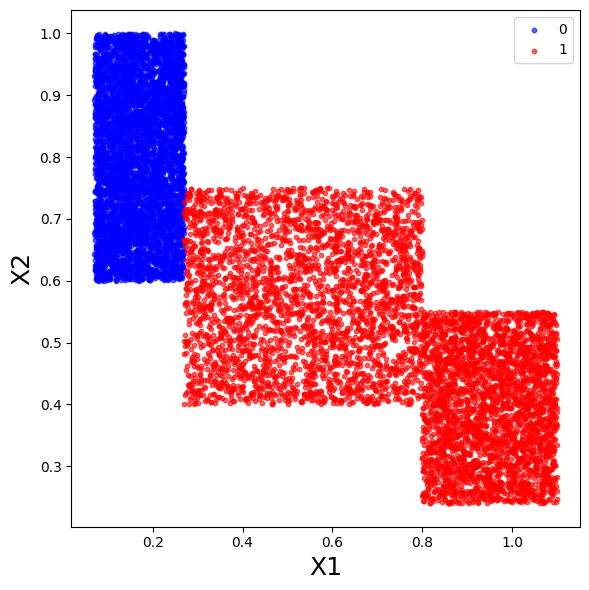

In [9]:
rule_info = [[l11, u11, l21, u21, y1], [l12, u12, l22, u22, y2], [l13, u13, l23, u23, y3]]
write_and_save_ruleset(rule_info, save_path = ruleset_save_path)
rule_limits = np.array([[l11, u11, l21, u21], [l12, u12, l22, u22], [l13, u13, l23, u23]])
# Set random seed
np.random.seed(102)

# Generate random points for each rule
R1, w1, h1 = get_rule_points(l11, u11, l21, u21, 5000)
R2, w2, h2 = get_rule_points(l12, u12, l22, u22, 3000)
R3, w3, h3 = get_rule_points(l13, u13, l23, u23, 3000)

data = np.vstack([np.column_stack([R1, np.zeros((len(R1),1))]), np.column_stack([R2, np.ones((len(R2),1))]), np.column_stack([R3, np.ones((len(R3),1))])])
indices = np.random.permutation(len(data))
data_shuffled = data[indices]

X = data_shuffled[:, :2]
Y = data_shuffled[:, -1]


scatter_colors = {0: "b", 1: "r"}
scatter_style = {0: "--", 1: "-"}

plt.figure(figsize=(6, 6))
plt.scatter(X[Y==0, 0], X[Y==0, 1], c="blue", s=10, label = "0", alpha=0.6)
plt.scatter(X[Y==1, 0], X[Y==1, 1], c="red", s=10, label = "1", alpha=0.6)
plt.xlabel("X1", fontsize = 18)
plt.ylabel("X2", fontsize = 18)
plt.legend()
plt.tight_layout()
if save_plots_flag:
    plt.savefig(res_path+"plots/synthetic_classes.png", dpi = 200, bbox_inches="tight")
plt.show()


data_combined = np.hstack([X, Y.reshape(-1, 1)])

df = pd.DataFrame(data_combined, columns=["X1", "X2", "output"])
df.to_excel(outfile, index=False)

# Data preparation
Split into train, test, calibration

In [10]:
# dt 

data_train_cal, data_ts = train_test_split(df, test_size=2000, random_state=102)

data_tr, data_cal = train_test_split(data_train_cal, test_size=5000, random_state=102)

y_train=data_tr["output"]
data_tr.drop(["output"],axis=1,inplace=True)

# Rule thresholds
nrules = len(rule_info)#.shape[0]

relevance = np.zeros(nrules)

Xts = data_ts.iloc[:, [0, 1]].to_numpy()
Yts = data_ts.iloc[:, 2].to_numpy()

Xcal = data_cal.iloc[:, [0, 1]].to_numpy()
Ycal = data_cal.iloc[:, 2].to_numpy()

n_c = Xcal.shape[0]


# **Compute rule similarity**

In [11]:
# parse the ruleset to extract each condition and fill each rule with missing thresholds
parsedruleset = clean_ruleset_file(ruleset_save_path, df, ["X1", "X2"], 2, "output")
parsedruleset.Feature = parsedruleset.Feature.astype("category")
parsedruleset.Feature = parsedruleset.Feature.cat.set_categories(["X1", "X2"])
parsedruleset = parsedruleset.sort_values(["Rule ID", "Feature"])


rulesim = GeneralizedIoU(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=True, save_path=res_path+rulesim_path) #RuleSimilarity(parsedruleset, rulesetfile=f"{res_path}/{rulesetfile_full}", SAVE_RS_VALUES=True, save_path=res_path+rulesim_path)
rulesim


array([[1.        , 0.7547848 , 0.44746898],
       [0.7547848 , 1.        , 0.59759388],
       [0.44746898, 0.59759388, 1.        ]])

In [12]:
ruleset_save_path

'results_adjacent_case_PR/synthetic_adjacent_case_PR.csv'

# **Perform conformal prediction pipeline**

# Compute calibration scores

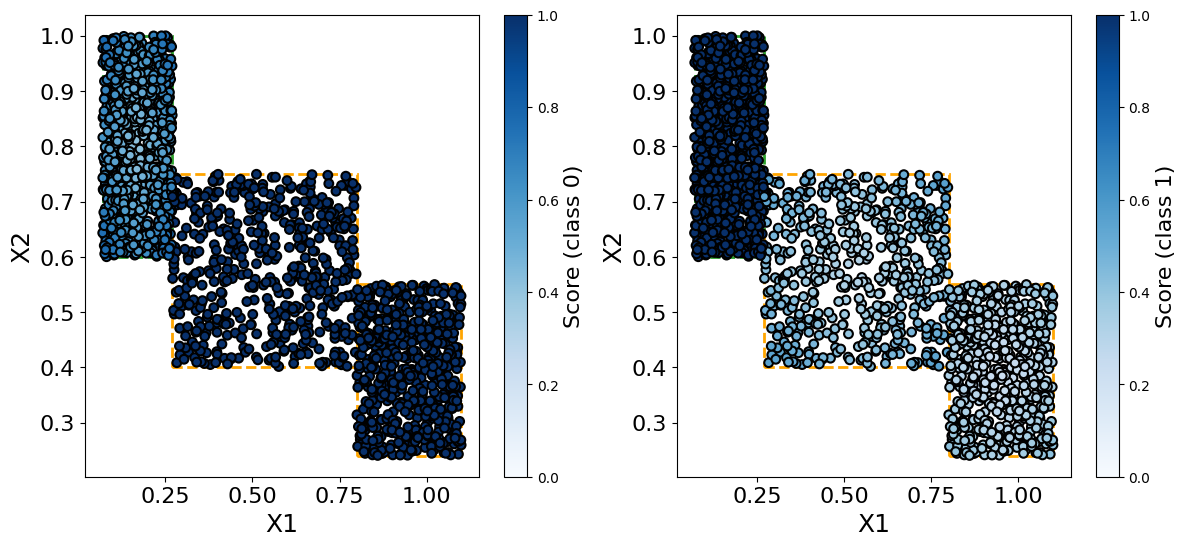

In [19]:
from matplotlib import colors
# check da qui
#rule_limits = np.array(rule_info)
tau0cal, Scal, gamma0cal,simterm0cal = compute_dataset_score(Xcal, rulesim, rule_limits, changeclsidx, 0, relevance)
tau1cal, _, gamma1cal,simterm1cal = compute_dataset_score(Xcal, rulesim, rule_limits, changeclsidx, 1, relevance)
tau0ts, Sts, _,_ = compute_dataset_score(Xts, rulesim, rule_limits, changeclsidx, 0, relevance)
tau1ts, _,_,_ = compute_dataset_score(Xts, rulesim, rule_limits, changeclsidx, 1, relevance)

selectedscores_cal = np.where(Ycal == 0, tau0cal, tau1cal)
norm = colors.Normalize(vmin=0, vmax=1)

wrong_0 = Xcal[(Ycal == 1) & ((Scal[:,:changeclsidx-1]==1).any(axis = 1)),:]
wrong_1 = Xcal[(Ycal == 0) & ((Scal[:,changeclsidx-1:]==1).any(axis = 1)),:]

wrong_0_ts = Xts[(Yts == 1) & ((Sts[:,:changeclsidx-1]==1).any(axis = 1)),:]
wrong_1_ts = Xts[(Yts == 0) & ((Sts[:,changeclsidx-1:]==1).any(axis = 1)),:]
# Plotting for tau0cal
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))

for r in range(rule_limits.shape[0]):
    if r<changeclsidx-1:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange',linestyle='--', facecolor='none'))

sc = ax1.scatter(Xts[:, 0], Xts[:, 1], c=tau0ts, cmap='Blues', norm=norm, s=40, edgecolors='black', linewidth=1.5, marker='o')

# TODO: visualizza score solo per questi
ax1.scatter(wrong_1_ts[:20, 0], wrong_1_ts[:20, 1], c='red', s=40, marker='x', linewidth=2)

cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Score (class 0)', fontsize=16)

ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
ax1.tick_params(labelsize=16)


sc = ax2.scatter(Xts[:, 0], Xts[:, 1], c= tau1ts, cmap='Blues', norm=norm, s=40, edgecolors='black', linewidth=1.5, marker='o')
ax2.scatter(wrong_0_ts[:20, 0], wrong_0_ts[:20, 1], c='red', s=40, marker='x', linewidth=2)


cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Score (class 1)', fontsize=16)

ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
ax2.tick_params(labelsize=16)
if save_plots_flag:
    plt.savefig(res_path+"plots/test_scores_confiderai.png", dpi = 200, bbox_inches="tight")
plt.show()


# Get prediction sets and evaluate on test set

avgErr:  [0.0095 0.0485 0.097  0.197 ]
avgSize:  [0.9905 0.9515 0.903  0.803 ]
avgSingle:  [0.9905 0.9515 0.903  0.803 ]
avgEmpty:  [0.0095 0.0485 0.097  0.197 ]
avgDouble:  [0. 0. 0. 0.]


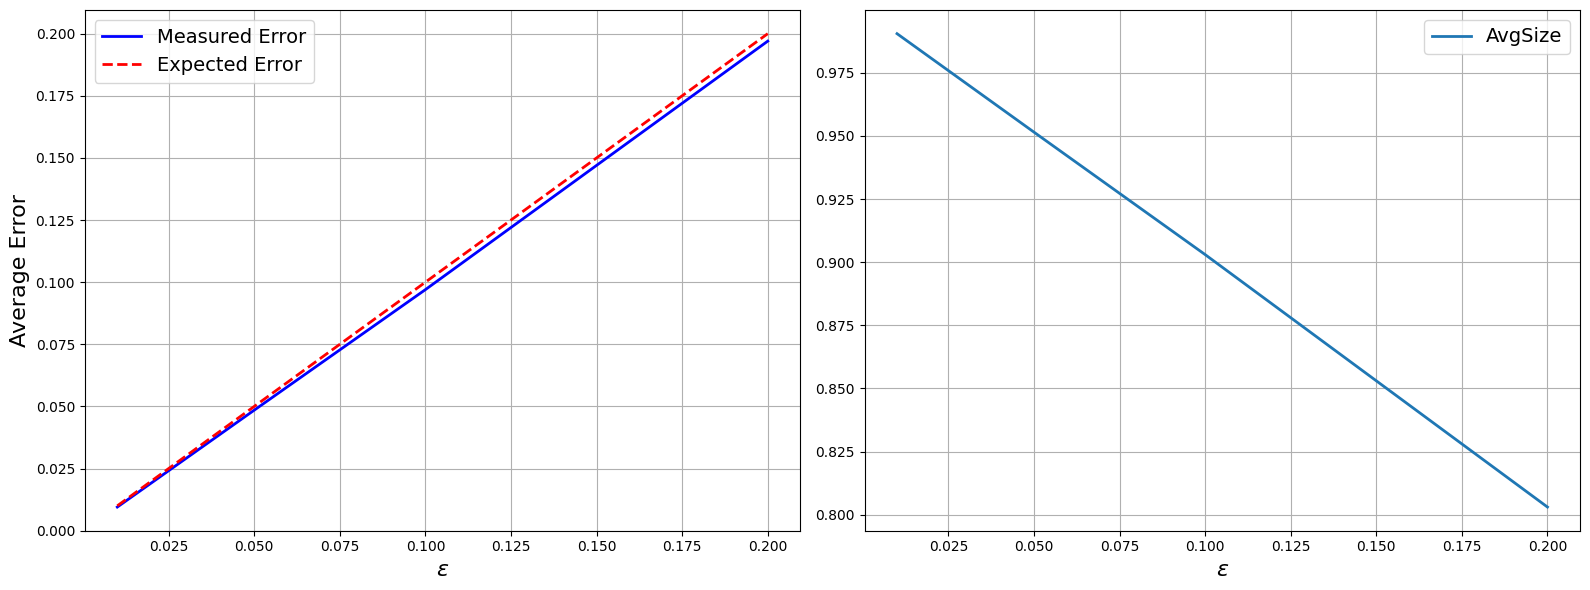

In [14]:


epsilonrange = [0.01, 0.05, 0.1, 0.2] #np.linspace(0.01, 0.5, 1000)
n_eps = len(epsilonrange)

avgErr = np.zeros(n_eps)
empty = np.zeros(n_eps)
singleton = np.zeros(n_eps)
double = np.zeros(n_eps)

avgSize = np.zeros(n_eps)
for i, epsilon in enumerate(epsilonrange):
    # Compute prediction regions
    C_all, s_epsilon, selectedscores, C_size = GetPredictionRegions(Ycal, tau0cal, tau1cal, tau0ts, tau1ts, epsilon, n_c)
    
    n_err = np.sum((Yts != C_all) & (C_all != 2))
    avgErr[i] = n_err / len(Xts)
    
    empty[i] = np.sum(C_size == 0) / len(Xts)
    singleton[i] = np.sum(C_size == 1) / len(Xts)
    double[i] = np.sum(C_size == 2) / len(Xts)
    avgSize[i] = np.sum(C_size)/len(Xts)
print("avgErr: ", avgErr)
print("avgSize: ", avgSize)
print("avgSingle: ", singleton)
print("avgEmpty: ", empty)
print("avgDouble: ", double)
# Plot with subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))


axs[0].plot(epsilonrange, avgErr, 'b', linewidth=2, label='Measured Error')
axs[0].plot(epsilonrange, epsilonrange, 'r--', linewidth=2, label='Expected Error')
axs[0].set_xlabel(r'$\varepsilon$', fontsize=16)
axs[0].set_ylabel("Average Error", fontsize=16)
axs[0].legend(fontsize=14)
axs[0].grid(True)


#axs[1].plot(epsilonrange, empty*100, linewidth=2, label='Empty')
#axs[1].plot(epsilonrange, singleton*100, linewidth=2, label='Single')
#axs[1].plot(epsilonrange, double*100, linewidth=2, label='Double')
axs[1].plot(epsilonrange, avgSize, linewidth=2, label='AvgSize')
axs[1].set_xlabel(r'$\varepsilon$', fontsize=16)
#axs[1].set_ylabel("%", fontsize=16)
axs[1].legend(fontsize=14)
axs[1].grid(True)

plt.tight_layout()
if save_plots_flag:
    plt.savefig(res_path+"plots/CP_metrics.png", dpi = 200, bbox_inches="tight")
plt.show()

# Calibration Scores Distribution

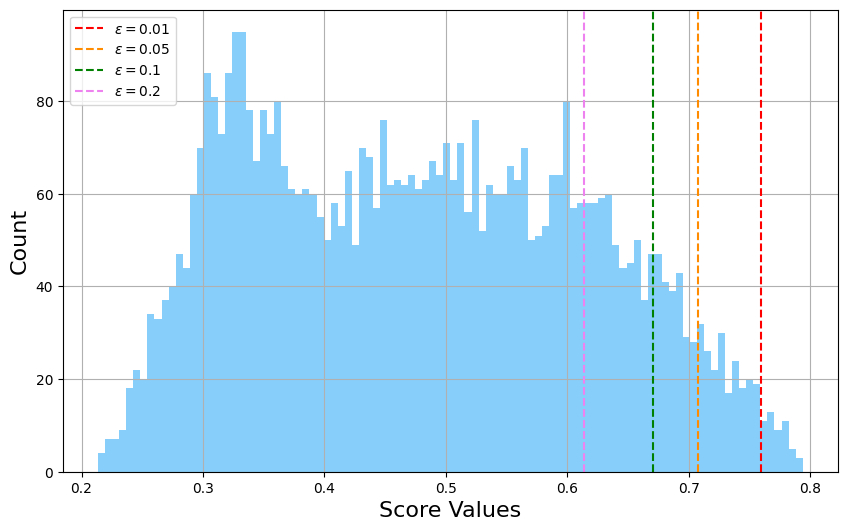

In [15]:
epsilon_vals = [0.01, 0.05, 0.1, 0.2]
fig, ax = plt.subplots(1,1,figsize=(10,6))
scores_calib_sorted = np.sort(selectedscores)

colors = ["red", "darkorange", "green", "violet"]
ax.hist(selectedscores, color = "lightskyblue", bins = 100)
for i, epsilon in enumerate(epsilon_vals):
    q_level = np.ceil((n_c + 1) * (1 - epsilon))/n_c
    s_epsilon = np.quantile(scores_calib_sorted, q_level)
    ax.axvline(x = s_epsilon, linestyle = "--", color=colors[i], label = fr"$\varepsilon={epsilon}$")
    ax.set_xlabel("Score Values", fontsize = 16)
    ax.set_ylabel("Count", fontsize = 16)
    ax.grid(True)
ax.legend()
if save_plots_flag:
    plt.savefig(res_path+"plots/CalibScoresDistribution.png", dpi = 200, bbox_inches="tight")
plt.show()

In [16]:
calib_scores_info = pd.DataFrame(zip(tau0cal,tau1cal,gamma0cal,gamma1cal, simterm0cal, simterm1cal, selectedscores, Ycal), columns=["score-0", "score-1","geom-0","geom-1","sim-0","sim-1","score-correct","Y_cal"])
calib_scores_info.to_excel(res_path+"scores_info_calib.xlsx", index=False)